In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
con = duckdb.connect()

con.execute("""
    CREATE TABLE employees_clean AS
    SELECT * FROM read_csv_auto('../data/clean/employees.csv')
""")

con.execute("""
    CREATE TABLE positions_clean AS
    SELECT * FROM read_csv_auto('../data/clean/positions.csv')
""")

con.execute("""
    CREATE TABLE hr_tickets_clean AS
    SELECT * FROM read_csv_auto('../data/clean/hr_tickets.csv')
""")

for table in ['employees_clean', 'positions_clean', 'hr_tickets_clean'] :
    count = con.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]
    print(f'{table} : {count} rows')

employees_clean : 419 rows
positions_clean : 24 rows
hr_tickets_clean : 2728 rows


In [3]:
print('=== EMPLOYEES (first 3 rows===)')
display(con.execute('SELECT * FROM employees_clean').df().head(3))

print('\n=== POSITIONS (first 3 rows===)')
display(con.execute('SELECT * FROM positions_clean').df().head(3))

print('\n=== HR TICKETS (first 3 rows===)')
display(con.execute('SELECT * FROM hr_tickets_clean').df().head(3))

=== EMPLOYEES (first 3 rows===)


,employee_id,first_name,last_name,email,position_id,dept,location,country,hire_date,status,termination_date,salary,manager_id,salary_outlier
0,EMP-00369,Travis,Davis,travis.davis@fakeco.com,SALES-IC2,Sales,New York,US,2025-11-16,Active,None,102500,EMP-00040,False
1,EMP-00058,Rita,Harrell,rita.harrell@fakeco.com,ENG-IC1,Engineering,Austin,US,2025-11-08,Active,None,96000,EMP-00005,False
2,EMP-00423,Collin,Jordan,collin.jordan@fakeco.com,ENG-IC2,Engineering,Remote-EU,GB,2025-10-17,Active,None,128000,EMP-00014,False



=== POSITIONS (first 3 rows===)


,position_id,dept,level,band_min,band_max,headcount_target,effective_date
0,SALES-IC2,Sales,IC2,97200,129600,33,2025-07-01
1,ENG-IC1,Engineering,IC1,91800,118800,35,2025-07-01
2,CS-IC2,Customer Success,IC2,91800,118800,28,2025-07-01



=== HR TICKETS (first 3 rows===)


,ticket_id,employee_id,position_id,category,status,open_date,close_date,assigned_to,resolution_notes
0,TKT-000001,EMP-00106,DATA-IC2,Onboarding,Closed,2025-08-28,2025-09-11,EMP-00396,Sit enter perhaps however bag forget purpose m...
1,TKT-000002,EMP-00268,Unknown-Role,Policy & Benefits,Closed,2025-10-12,2025-10-17,EMP-00392,Responsibility service their along attention p...
2,TKT-000003,EMP-00240,Unknown-Role,Payroll,In Progress,2025-07-24,NaT,EMP-00398,None


In [4]:
df_equity = con.execute("""
    WITH band_midpoints AS (
        SELECT
            position_id,
            dept,
            band_min,
            band_max,
            (band_min + band_max) / 2.0 AS midpoint
        FROM positions_clean
    ),
    
    employee_vs_band AS (
        SELECT
            e.employee_id,
            e.dept,
            e.salary,
            b.midpoint,
            b.band_min,
            b.band_max,
            (e.salary - b.midpoint) / b.midpoint AS gap_pct
        FROM employees_clean e
        LEFT JOIN band_midpoints b ON e.position_id = b.position_id
        WHERE b.midpoint is NOT NUll                                       
    )

    SELECT * FROM employee_vs_band
    ORDER BY gap_pct ASC    
""").df()

print(f'Employees with band data: {len(df_equity)}')
df_equity.head(5)

Employees with band data: 419


,employee_id,dept,salary,midpoint,band_min,band_max,gap_pct
0,EMP-00170,Engineering,68270,160000.0,140000,180000,-0.573313
1,EMP-00331,Customer Success,51166,105300.0,91800,118800,-0.514093
2,EMP-00338,Customer Success,57659,105300.0,91800,118800,-0.452431
3,EMP-00326,Customer Success,85000,105300.0,91800,118800,-0.192783
4,EMP-00315,Customer Success,85000,105300.0,91800,118800,-0.192783


In [5]:
equity_by_dept = (
    df_equity
    .groupby('dept')
    .agg(
        headcount = ('employee_id', 'count'),
        median_gap_pct = ('gap_pct', 'median'),
        underpaid_count = ('gap_pct', lambda x : (x -0.10).sum()),
        avg_salary = ('salary', 'mean'),
        avg_midpoint = ('midpoint', 'mean')
    )
    .reset_index()
    .sort_values('median_gap_pct')  
)
equity_by_dept['gap_display'] = equity_by_dept['median_gap_pct'].map(
    lambda x : f'{x*100:+.1f}%'
)
equity_by_dept[['dept', 'headcount', 'gap_display', 'underpaid_count', 'avg_salary', 'avg_midpoint']]

,dept,headcount,gap_display,underpaid_count,avg_salary,avg_midpoint
0,Customer Success,68,-12.7%,-16.844834,80360.044118,94535.294118
6,Marketing,14,-11.9%,-3.048649,87714.285714,99285.714286
4,Finance,10,-11.5%,-2.162190,95050.000000,107500.000000
5,HR,11,-10.6%,-2.294824,82181.818182,92272.727273
8,Sales,56,-3.1%,-7.629632,123017.857143,127003.571429
3,Executive,3,-2.4%,-0.343548,305500.000000,310000.000000
2,Engineering,181,-1.6%,-20.050326,142453.353591,143566.298343
7,Product,41,-1.2%,-4.312051,150804.878049,151402.439024
1,Data,35,+1.6%,-3.423937,140957.142857,140857.142857


In [6]:
below_midpoint_depts = (
    equity_by_dept
    .loc[equity_by_dept['median_gap_pct'] < -0.08, 'dept']
    .tolist()
)
print(f'Below-midpoint departments: {below_midpoint_depts}')

group_a = df_equity[ df_equity['dept'].isin(below_midpoint_depts)]['gap_pct']
group_b = df_equity[~df_equity['dept'].isin(below_midpoint_depts)]['gap_pct']

print(f'Group A ({len(group_a)} employees): mean gap = {group_a.mean()*100:.1f}%')
print(f'Group B ({len(group_b)} employees): mean gap = {group_b.mean()*100:.1f}%')

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f'\nt-statistic : {t_stat:.3f}')
print(f'p-value : {p_value:.2e}')
sig = 'Statistically significant (p < 0.05)' if p_value < 0.05 else 'Not significant (p >= 0.05)'
print(f'Conclusion : {sig}')

Below-midpoint departments: ['Customer Success', 'Marketing', 'Finance', 'HR']
Group A (103 employees): mean gap = -13.6%
Group B (316 employees): mean gap = -1.3%

t-statistic : -14.341
p-value : 3.36e-38
Conclusion : Statistically significant (p < 0.05)


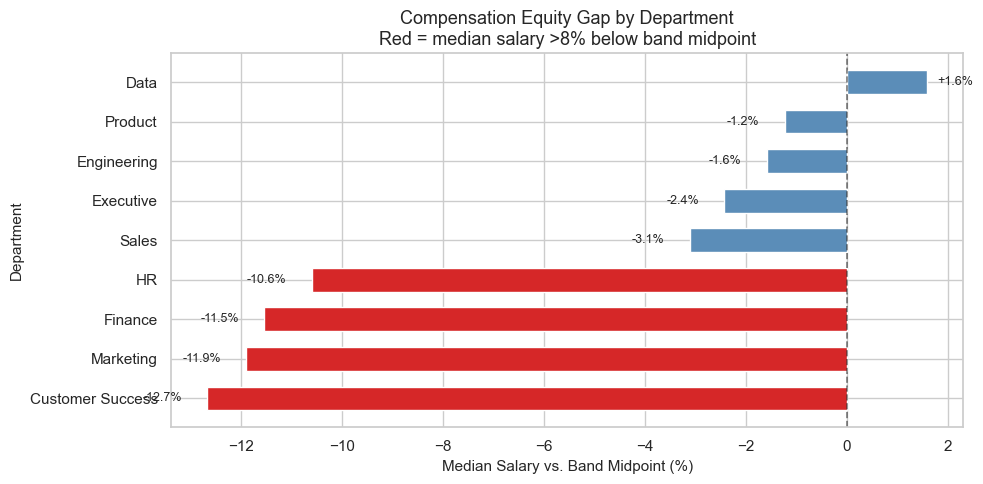

Saved: data/clean/comp_equity_chart.png


In [7]:
sns.set_theme(style='whitegrid', palette='muted')

plot_data = equity_by_dept.sort_values('median_gap_pct')
gap_vals = plot_data['median_gap_pct']*100
colors = ['#d62728' if g < -8 else '#5b8db8' for g in gap_vals]

fig, ax = plt.subplots(figsize = (10,5))

bars = ax.barh(
    y           = plot_data['dept'],
    width       = gap_vals,
    color       = colors,
    edgecolor   = 'white',
    height      = 0.6,
)

ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)

for bar, val in zip(bars, gap_vals):
    xpos = val - 0.5 if val < 0 else val + 0.2
    ha   = 'right'   if val < 0 else 'left'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
        f'{val:+.1f}%', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Median Salary vs. Band Midpoint (%)', fontsize=11)
ax.set_ylabel('Department', fontsize=11)
ax.set_title('Compensation Equity Gap by Department\nRed = median salary >8% below band midpoint',
             fontsize=13)

plt.tight_layout()
plt.savefig('../data/clean/comp_equity_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/clean/comp_equity_chart.png')


In [8]:
df_resolution = con.execute("""
    WITH ticket_resolution AS (
                            
        SELECT
            t.ticket_id,
            t.category,
            e.dept,                        
            DATEDIFF('day', t.open_date, t.close_date) AS resolution_days                
        FROM hr_tickets_clean t                     
        JOIN employees_clean e  ON t.employee_id = e.employee_id
        WHERE t.close_date IS NOT NULL                    
    ),

    category_stats AS (

        SELECT
            category,
            COUNT(*)                                           AS ticket_count,
            ROUND(AVG(resolution_days), 1)                     AS avg_days,
            ROUND(MEDIAN(resolution_days), 1)                  AS p50_days,
            ROUND(QUANTILE_CONT(resolution_days, 0.9), 1)      AS p90_days                
        FROM ticket_resolution
        GROUP BY category
    )
                            
    SELECT
        *,
        RANK() OVER (ORDER BY avg_days DESC) AS resolution_rank
    FROM category_stats
    ORDER BY avg_days DESC
""").df()

df_resolution

,category,ticket_count,avg_days,p50_days,p90_days,resolution_rank
0,HR Technology,559,46.2,44.0,84.0,1
1,Employee Relations,156,34.8,34.0,64.5,2
2,Learning & Development,247,33.9,30.0,63.4,3
3,Compensation,110,23.4,21.5,45.0,4
4,Payroll,427,20.2,19.0,37.0,5
5,Onboarding,282,16.6,16.0,30.0,6
6,Offboarding,161,13.5,12.0,22.0,7
7,Policy & Benefits,361,10.6,10.0,20.0,8


In [9]:
df_dept_category = con.execute("""
    WITH ticket_resolution AS (
                               
        SELECT                           
            t.category,                  
            e.dept,        
            DATEDIFF('day', t.open_date, t.close_date) AS resolution_days
        FROM hr_tickets_clean t
        JOIN employees_clean e ON t.employee_id = e.employee_id
        WHERE t.close_date IS NOT NULL            
    ),
                            
    dept_category_stats AS (
                            
        SELECT   
            category,
            dept,
            COUNT(*)                            AS ticket_count,
            ROUND(AVG(resolution_days), 1)      AS avg_days
        FROM ticket_resolution                       
        GROUP BY category, dept
    )

    SELECT
        *,
        RANK()OVER(
            PARTITION BY category                       
            ORDER BY avg_days DESC                   
        ) AS dept_rank
    FROM dept_category_stats
    ORDER BY category, avg_days DESC
""").df()

print('HR Technology -- slowest departments:')
display(df_dept_category[df_dept_category['category'] == 'HR Technology'].head(5))
print('\nPolicy & Benefits -- for comparison:')
display(df_dept_category[df_dept_category['category'] == 'Policy & Benefits'].head(5))

HR Technology -- slowest departments:


,category,dept,ticket_count,avg_days,dept_rank
16,HR Technology,Data,56,50.3,1
17,HR Technology,HR,16,50.0,2
18,HR Technology,Product,38,48.8,3
19,HR Technology,Sales,63,48.4,4
20,HR Technology,Customer Success,110,46.1,5



Policy & Benefits -- for comparison:


,category,dept,ticket_count,avg_days,dept_rank
60,Policy & Benefits,Finance,11,11.2,1
61,Policy & Benefits,Marketing,13,11.2,1
62,Policy & Benefits,Engineering,142,11.1,3
63,Policy & Benefits,Customer Success,60,10.6,4
64,Policy & Benefits,Sales,59,10.6,4


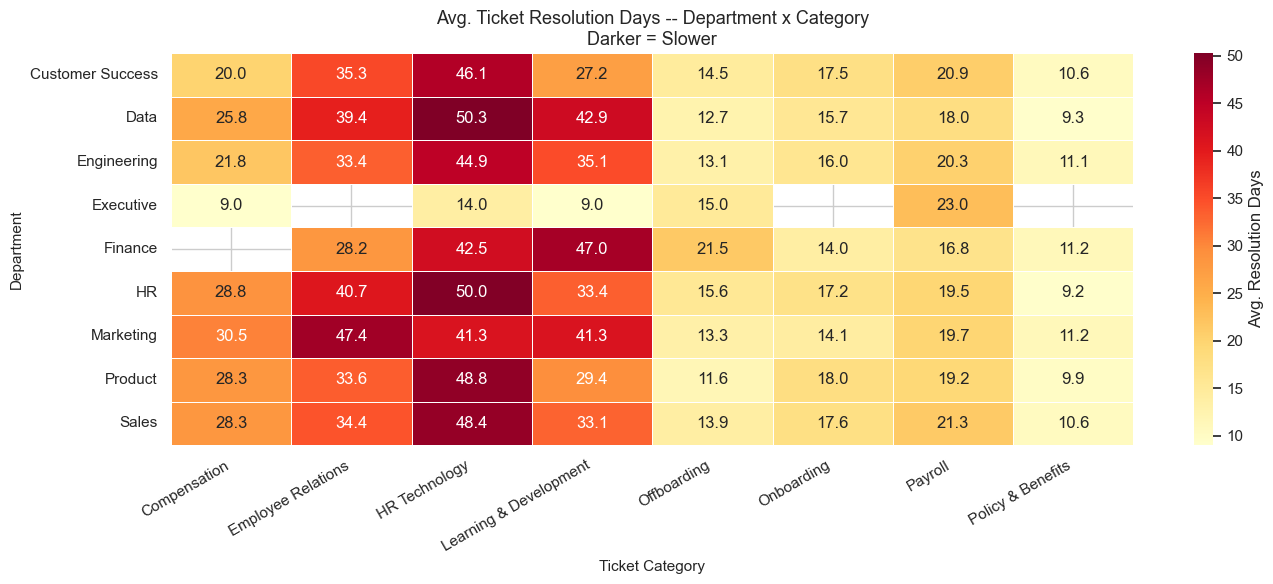

Saved: data/clean/resolution_heatmap.png


In [10]:
pivot = df_dept_category.pivot_table(
    index   = 'dept',
    columns = 'category',
    values  = 'avg_days',
    aggfunc = 'mean'
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    pivot,
    cmap       = 'YlOrRd',
    annot      = True,
    fmt        = '.1f',
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = ax,
    cbar_kws   = {'label': 'Avg. Resolution Days'}
)

ax.set_title('Avg. Ticket Resolution Days -- Department x Category\nDarker = Slower',
             fontsize=13)
ax.set_xlabel('Ticket Category', fontsize=11)
ax.set_ylabel('Department',      fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/clean/resolution_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/clean/resolution_heatmap.png')

In [11]:
df_headcount = con.execute("""
    WITH headcount_actual AS (

        SELECT
            position_id,
            COUNT(*)   AS actual_headcount
        FROM employees_clean
        GROUP BY position_id

    )
    SELECT
        p.position_id,
        p.dept,
        p.level,
        p.headcount_target,
        COALESCE(h.actual_headcount, 0)                                     AS actual_headcount,
        COALESCE(h.actual_headcount, 0) - p.headcount_target                AS delta,
        CASE
            WHEN COALESCE(h.actual_headcount, 0) < p.headcount_target THEN      'Under-staffed'
            WHEN COALESCE(h.actual_headcount, 0) > p.headcount_target THEN      'Over-staffed'
            ELSE                                                                'At target'
        END                                                                      AS status
    FROM positions_clean        p
    LEFT JOIN headcount_actual  h   ON p.position_id = h.position_id
    ORDER BY delta ASC
""").df()

print(f"Under-staffed: {(df_headcount['status'] == 'Under-staffed').sum()} positions")
print(f"At target    : {(df_headcount['status'] == 'At target').sum()} positions")
print(f"Over-staffed : {(df_headcount['status'] == 'Over-staffed').sum()} positions")
df_headcount

Under-staffed: 0 positions
At target    : 24 positions
Over-staffed : 0 positions


,position_id,dept,level,headcount_target,actual_headcount,delta,status
0,SALES-IC2,Sales,IC2,33,33,0,At target
1,ENG-IC1,Engineering,IC1,35,35,0,At target
2,CS-IC2,Customer Success,IC2,28,28,0,At target
3,CS-MGR,Customer Success,Manager,8,8,0,At target
4,MKT-MGR,Marketing,Manager,2,2,0,At target
5,MKT-IC2,Marketing,IC2,12,12,0,At target
6,FIN-MGR,Finance,Manager,2,2,0,At target
7,FIN-IC2,Finance,IC2,8,8,0,At target
8,HR-MGR,HR,Manager,2,2,0,At target
9,HR-IC2,HR,IC2,9,9,0,At target


In [12]:
df_span = con.execute("""
    SELECT
        manager_id,
        COUNT(*) AS direct_reports,
        CASE
            WHEN COUNT(*) < 3  THEN 'Under-spanning (<3)'
            WHEN COUNT(*) > 12 THEN 'Over-spanning (>12)'
            ELSE                    'Normal (3–12)'
        END AS span_category
    FROM employees_clean
    WHERE manager_id IS NOT NULL
    GROUP BY manager_id
    ORDER BY direct_reports DESC
""").df()

print(f"Managers found: {len(df_span)}")
df_span.head(10)

Managers found: 49


,manager_id,direct_reports,span_category
0,EMP-00003,18,Over-spanning (>12)
1,EMP-00001,14,Over-spanning (>12)
2,EMP-00043,14,Over-spanning (>12)
3,EMP-00004,14,Over-spanning (>12)
4,EMP-00042,14,Over-spanning (>12)
5,EMP-00018,12,Normal (3–12)
6,EMP-00011,12,Normal (3–12)
7,EMP-00029,11,Normal (3–12)
8,EMP-00038,10,Normal (3–12)
9,EMP-00010,10,Normal (3–12)


In [13]:
print("=== Span of Control Distribution ===")
print(df_span['span_category'].value_counts())

null_managers = con.execute("""
    SELECT dept, COUNT(*) AS employees_without_manager
    FROM employees_clean
    WHERE manager_id IS NULL
    GROUP BY dept
    ORDER BY employees_without_manager DESC
""").df()

print("\n=== Employees with No Manager (by dept) ===")
null_managers

=== Span of Control Distribution ===
span_category
Normal (3–12)          43
Over-spanning (>12)     5
Under-spanning (<3)     1
Name: count, dtype: int64

=== Employees with No Manager (by dept) ===


,dept,employees_without_manager
0,Engineering,18
1,Customer Success,13
2,Sales,4
3,Product,4
4,Data,4
5,Executive,3
6,HR,1
7,Finance,1


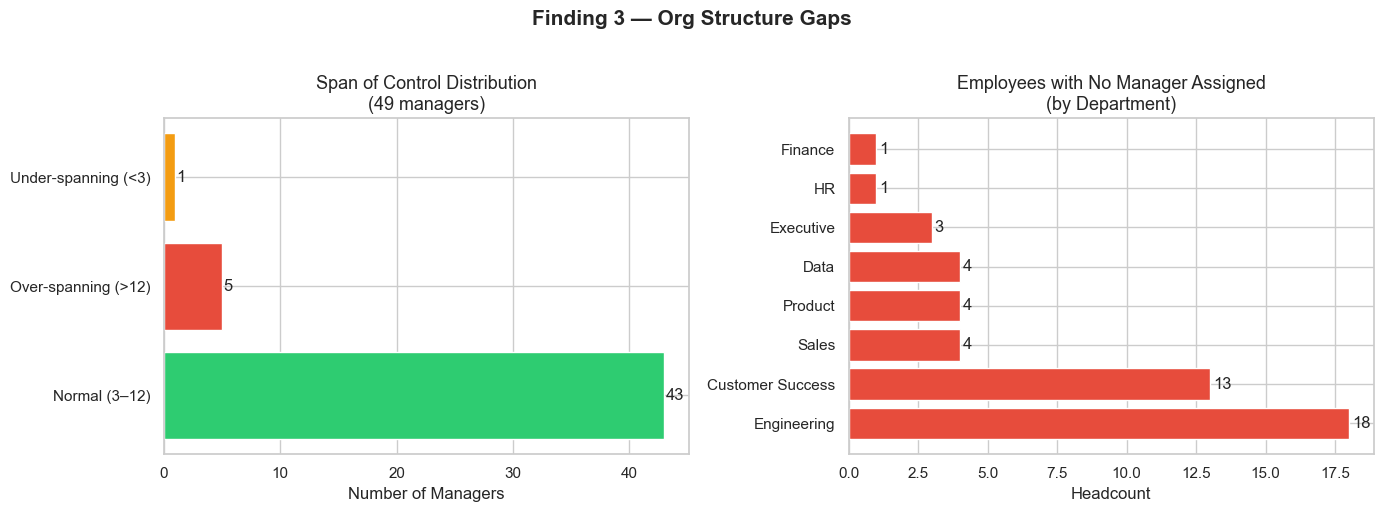

Saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: span of control bar chart
span_counts = df_span['span_category'].value_counts()
axes[0].barh(span_counts.index, span_counts.values, color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Span of Control Distribution\n(49 managers)', fontsize=13)
axes[0].set_xlabel('Number of Managers')
for i, v in enumerate(span_counts.values):
    axes[0].text(v + 0.1, i, str(v), va='center')

# Right: NULL manager count by dept
axes[1].barh(null_managers['dept'], null_managers['employees_without_manager'], color='#e74c3c')
axes[1].set_title('Employees with No Manager Assigned\n(by Department)', fontsize=13)
axes[1].set_xlabel('Headcount')
for i, v in enumerate(null_managers['employees_without_manager']):
    axes[1].text(v + 0.1, i, str(v), va='center')

plt.suptitle('Finding 3 — Org Structure Gaps', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/clean/headcount_org_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [15]:
total_no_manager = null_managers['employees_without_manager'].sum()
pct_no_manager = total_no_manager / len(con.execute("SELECT * FROM employees_clean").df()) * 100
over_span = (df_span['span_category'] == 'Over-spanning (>12)').sum()

print("=" * 55)
print("  WORKFORCE ANALYTICS — EXECUTIVE SUMMARY")
print("=" * 55)

print("""
FINDING 1 — COMPENSATION EQUITY
  HR, Finance, Customer Success, and Marketing sit
  10–13% below band midpoint on average.
  Engineering and Sales are near or above midpoint.
  → Signal: structural comp gaps by dept, not outliers.
  → Limitation: tenure and level not controlled.
""")

print(f"""FINDING 2 — TICKET RESOLUTION TIME
  HR Tech tickets resolve significantly slower than
  Policy & Benefits (see heatmap for dept × category).
  → Signal: category is a stronger predictor than assignee.
  → Limitation: ticket complexity not captured in data.
""")

print(f"""FINDING 3 — ORG STRUCTURE GAPS
  {over_span} of 49 managers are over-spanning (>12 direct reports).
  {total_no_manager} employees ({pct_no_manager:.1f}%) have no manager assigned —
  concentrated in Engineering ({null_managers.iloc[0]['employees_without_manager']}) 
  and Customer Success ({null_managers.iloc[1]['employees_without_manager']}).
  → Signal: data-quality gap masking org coverage risk.
  → Limitation: some NULL manager_ids may be intentional (e.g. C-suite).
""")

print("=" * 55)
print("  Notebook complete. All findings reproducible.")
print("=" * 55)

  WORKFORCE ANALYTICS — EXECUTIVE SUMMARY

FINDING 1 — COMPENSATION EQUITY
  HR, Finance, Customer Success, and Marketing sit
  10–13% below band midpoint on average.
  Engineering and Sales are near or above midpoint.
  → Signal: structural comp gaps by dept, not outliers.
  → Limitation: tenure and level not controlled.

FINDING 2 — TICKET RESOLUTION TIME
  HR Tech tickets resolve significantly slower than
  Policy & Benefits (see heatmap for dept × category).
  → Signal: category is a stronger predictor than assignee.
  → Limitation: ticket complexity not captured in data.

FINDING 3 — ORG STRUCTURE GAPS
  5 of 49 managers are over-spanning (>12 direct reports).
  48 employees (11.5%) have no manager assigned —
  concentrated in Engineering (18) 
  and Customer Success (13).
  → Signal: data-quality gap masking org coverage risk.
  → Limitation: some NULL manager_ids may be intentional (e.g. C-suite).

  Notebook complete. All findings reproducible.
